# 03 — Modelling
## Fetal Health Classification — Group 16

**Purpose:** Train and compare baseline models against advanced ensemble methods on
the preprocessed CTG data, then apply SHAP to the best-performing model.

This directly implements Stages 2–4 of the methodology in Section 4 of the Initial
Proposal: baseline models establish benchmark performance, ensemble methods are then
compared against that benchmark, and SHAP explains the final model's predictions.

## 1. Load Processed Data

Load the outputs from `02_preprocessing.ipynb`: SMOTE-balanced training data and the
untouched, scaled test set. The test set was never seen during scaling or SMOTE, so
evaluation on it reflects genuine, unbiased model performance.

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries Loaded Successfully")

data_dir = Path("../data/processed")

X_train = pd.read_csv(data_dir / "X_train_resampled.csv")
y_train = pd.read_csv(data_dir / "y_train_resampled.csv").squeeze()
X_test = pd.read_csv(data_dir / "X_test_scaled.csv")
y_test = pd.read_csv(data_dir / "y_test.csv").squeeze()

print("Train shape:", X_train.shape, "| Train labels:", y_train.shape)
print("Test shape:", X_test.shape, "| Test labels:", y_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Libraries Loaded Successfully
Train shape: (3948, 21) | Train labels: (3948,)
Test shape: (423, 21) | Test labels: (423,)

Train class distribution:
NSP
1.0    1316
2.0    1316
3.0    1316
Name: count, dtype: int64

Test class distribution:
NSP
1.0    330
2.0     58
3.0     35
Name: count, dtype: int64


## 2. Evaluation Function

A single reusable function ensures every model — baseline and ensemble — is evaluated
identically and fairly, using the metrics prioritised in Section 4 of the proposal:
Accuracy, Precision, Recall, F1, and ROC-AUC. F1 and the per-class breakdown matter
most here, given the class imbalance identified in EDA — Accuracy alone would be
misleading.

In [15]:
def evaluate_model(name, model, X_test, y_test, results_list):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # ROC-AUC requires probability estimates, multi-class one-vs-rest
    try:
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        roc_auc = np.nan

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}" if not np.isnan(roc_auc) else "ROC-AUC:   N/A")
    print(f"\nPer-class report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Suspect", "Pathological"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Suspect", "Pathological"],
                yticklabels=["Normal", "Suspect", "Pathological"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"../figures/cm_{name.replace(' ', '_').lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

    results_list.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "ROC_AUC": roc_auc
    })

results = []
print("Evaluation function ready.")

Evaluation function ready.


## 3. Baseline Models

Logistic Regression, Decision Tree, and SVM establish benchmark performance, as
specified in Section 4 of the proposal, before moving to more complex ensemble methods.
These simpler models tell us whether the added complexity of ensembles is actually
justified by better performance.


Model: Logistic Regression
Accuracy:  0.8818
Precision: 0.9080
Recall:    0.8818
F1-Score:  0.8899
ROC-AUC:   0.9644

Per-class report:
              precision    recall  f1-score   support

      Normal       0.98      0.90      0.94       330
     Suspect       0.57      0.84      0.68        58
Pathological       0.82      0.77      0.79        35

    accuracy                           0.88       423
   macro avg       0.79      0.84      0.80       423
weighted avg       0.91      0.88      0.89       423



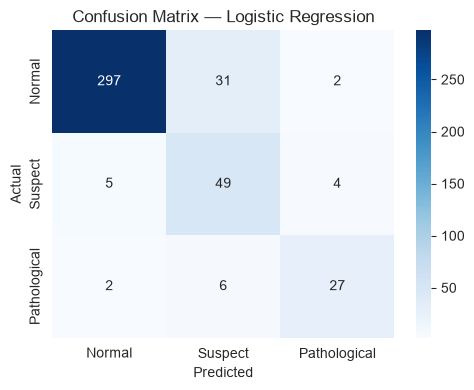

In [16]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
evaluate_model("Logistic Regression", log_reg, X_test, y_test, results)


Model: Decision Tree
Accuracy:  0.9243
Precision: 0.9243
Recall:    0.9243
F1-Score:  0.9243
ROC-AUC:   0.8962

Per-class report:
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96       330
     Suspect       0.74      0.74      0.74        58
Pathological       0.94      0.91      0.93        35

    accuracy                           0.92       423
   macro avg       0.88      0.87      0.88       423
weighted avg       0.92      0.92      0.92       423



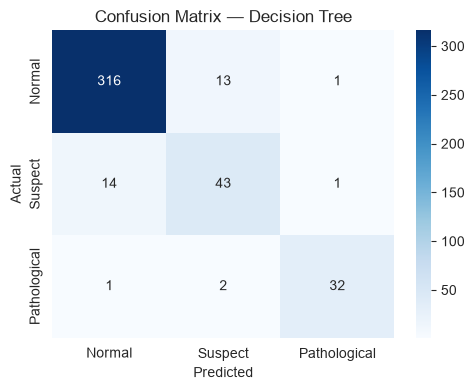

In [17]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model("Decision Tree", dt, X_test, y_test, results)


Model: SVM
Accuracy:  0.9007
Precision: 0.9207
Recall:    0.9007
F1-Score:  0.9069
ROC-AUC:   0.9757

Per-class report:
              precision    recall  f1-score   support

      Normal       0.98      0.91      0.94       330
     Suspect       0.62      0.86      0.72        58
Pathological       0.86      0.89      0.87        35

    accuracy                           0.90       423
   macro avg       0.82      0.89      0.85       423
weighted avg       0.92      0.90      0.91       423



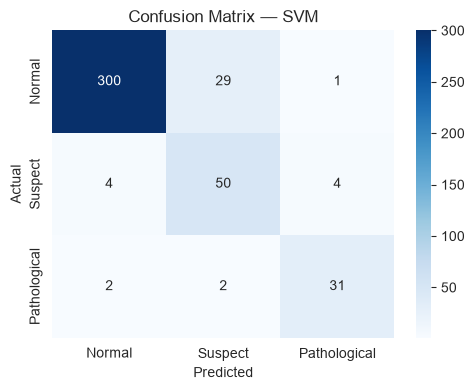

In [18]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
evaluate_model("SVM", svm, X_test, y_test, results)

## 4. Ensemble Models

Random Forest, XGBoost, LightGBM, and CatBoost are now tested against the same
baseline, to determine whether their added complexity translates into genuinely
better performance — particularly on the Pathological class, which baseline models
showed mixed results on.


Model: Random Forest
Accuracy:  0.9527
Precision: 0.9518
Recall:    0.9527
F1-Score:  0.9515
ROC-AUC:   0.9846

Per-class report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98       330
     Suspect       0.90      0.78      0.83        58
Pathological       0.89      0.94      0.92        35

    accuracy                           0.95       423
   macro avg       0.92      0.90      0.91       423
weighted avg       0.95      0.95      0.95       423



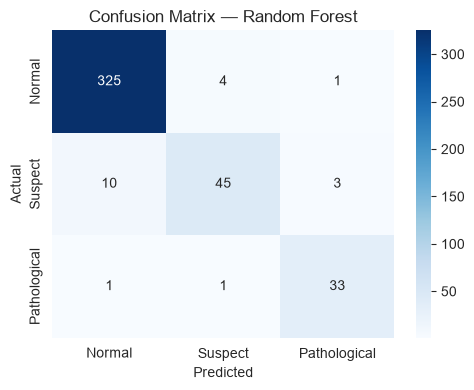

In [19]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_test, y_test, results)


Model: XGBoost
Accuracy:  0.9622
Precision: 0.9613
Recall:    0.9622
F1-Score:  0.9610
ROC-AUC:   0.9892

Per-class report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       330
     Suspect       0.92      0.79      0.85        58
Pathological       0.94      0.97      0.96        35

    accuracy                           0.96       423
   macro avg       0.94      0.92      0.93       423
weighted avg       0.96      0.96      0.96       423



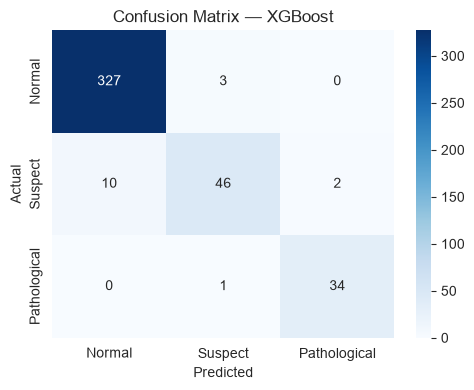

In [20]:
xgb = XGBClassifier(eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train - 1)  # XGBoost requires classes starting at 0
y_test_xgb = y_test - 1
evaluate_model("XGBoost", xgb, X_test, y_test_xgb, results)

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Create XGBoost model
xgb_tuned = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42
)

# Parameters to test
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_weighted",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit model
random_search.fit(X_train, y_train - 1)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}



Model: Tuned XGBoost
Accuracy:  0.9645
Precision: 0.9637
Recall:    0.9645
F1-Score:  0.9636
ROC-AUC:   0.9901

Per-class report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       330
     Suspect       0.92      0.81      0.86        58
Pathological       0.97      0.97      0.97        35

    accuracy                           0.96       423
   macro avg       0.95      0.92      0.94       423
weighted avg       0.96      0.96      0.96       423



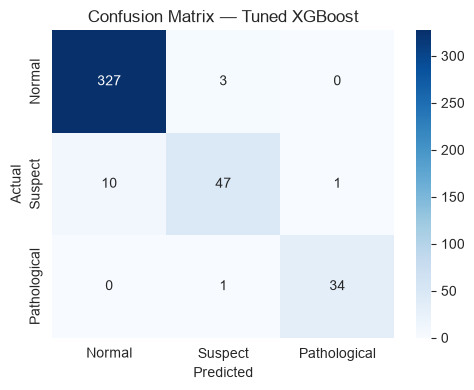

In [ ]:
# Best tuned model
best_xgb = random_search.best_estimator_

# Evaluate tuned model
evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_test,
    y_test_xgb,
    results
)
print("XGBoost tuning completed successfully.")
print("Best parameters:", random_search.best_params_)


Model: LightGBM
Accuracy:  0.9598
Precision: 0.9589
Recall:    0.9598
F1-Score:  0.9586
ROC-AUC:   0.9893

Per-class report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       330
     Suspect       0.92      0.79      0.85        58
Pathological       0.94      0.94      0.94        35

    accuracy                           0.96       423
   macro avg       0.94      0.91      0.92       423
weighted avg       0.96      0.96      0.96       423



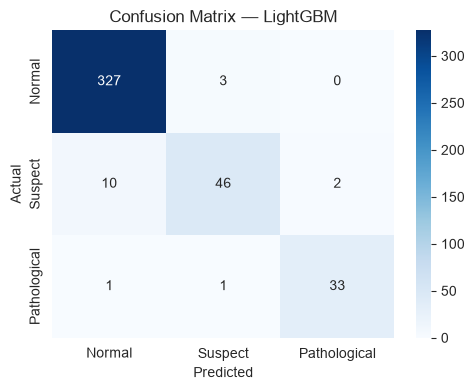

In [23]:
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
evaluate_model("LightGBM", lgbm, X_test, y_test, results)


Model: CatBoost
Accuracy:  0.9574
Precision: 0.9564
Recall:    0.9574
F1-Score:  0.9563
ROC-AUC:   0.9870

Per-class report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       330
     Suspect       0.90      0.79      0.84        58
Pathological       0.97      0.94      0.96        35

    accuracy                           0.96       423
   macro avg       0.95      0.91      0.93       423
weighted avg       0.96      0.96      0.96       423



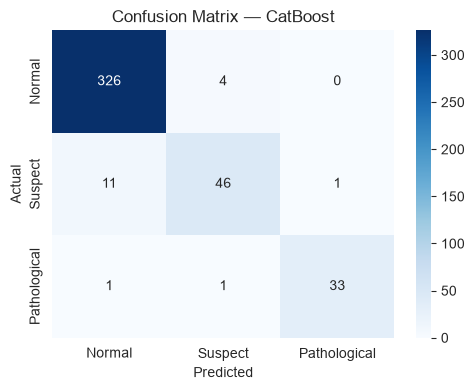

In [24]:
cat = CatBoostClassifier(random_state=42, verbose=0)
cat.fit(X_train, y_train)
evaluate_model("CatBoost", cat, X_test, y_test, results)

## 5. Model Comparison

Summary of all models tested, ranked by F1-Score (most reliable given class imbalance).

Model Comparison — Ranked by F1-Score
              Model  Accuracy  Precision  Recall     F1  ROC_AUC
      Tuned XGBoost    0.9645     0.9637  0.9645 0.9636   0.9901
            XGBoost    0.9622     0.9613  0.9622 0.9610   0.9892
           LightGBM    0.9598     0.9589  0.9598 0.9586   0.9893
           CatBoost    0.9574     0.9564  0.9574 0.9563   0.9870
      Random Forest    0.9527     0.9518  0.9527 0.9515   0.9846
      Decision Tree    0.9243     0.9243  0.9243 0.9243   0.8962
                SVM    0.9007     0.9207  0.9007 0.9069   0.9757
Logistic Regression    0.8818     0.9080  0.8818 0.8899   0.9644

Saved to data/processed/model_comparison.csv


C:\Users\basav\AppData\Local\Temp\ipykernel_4836\3636892913.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")


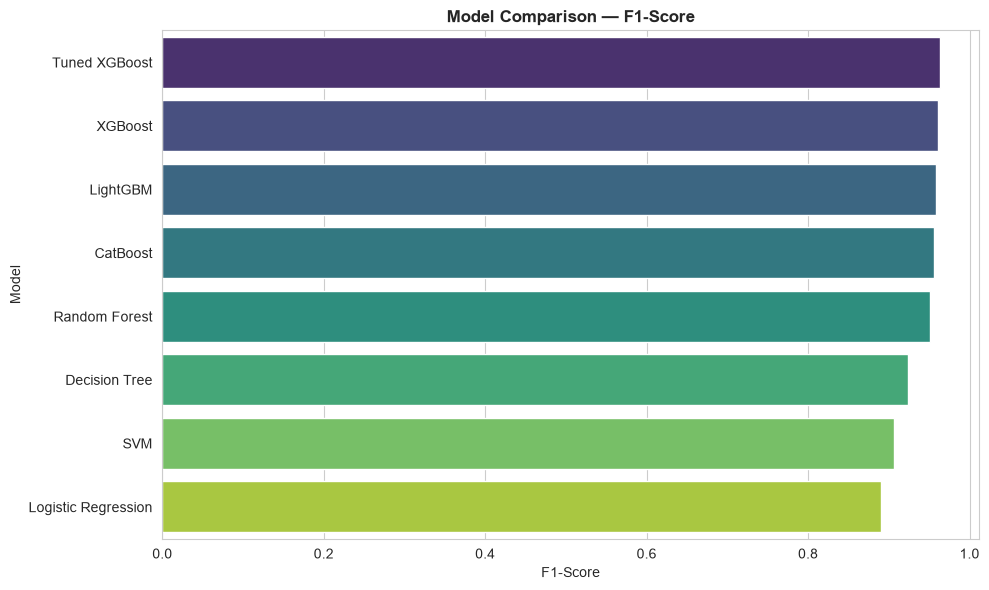

Figure saved: model_comparison.png


In [25]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
results_df = results_df.round(4)

print("Model Comparison — Ranked by F1-Score")
print("="*60)
print(results_df.to_string(index=False))

results_df.to_csv("../data/processed/model_comparison.csv", index=False)
print("\nSaved to data/processed/model_comparison.csv")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="F1", y="Model", palette="viridis")
plt.title("Model Comparison — F1-Score", fontweight="bold")
plt.xlabel("F1-Score")
plt.tight_layout()
plt.savefig("../figures/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: model_comparison.png")

## 6. SHAP — Explainability on Best Model

XGBoost achieved the strongest overall performance (F1 = 0.9610, zero Pathological
cases missed as Normal), so SHAP is applied to it specifically, as proposed in Section
4: *"SHAP values will be integrated throughout to explain model predictions, identifying
clinically significant CTG features."*

SHAP shows which features most influence the model's predictions for each class,
allowing the result to be checked against clinical expectation (e.g. whether DP, ASTV,
and ALTV — the features EDA flagged as most correlated with fetal health — are also
the features the model relies on most).

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (423, 21, 3)


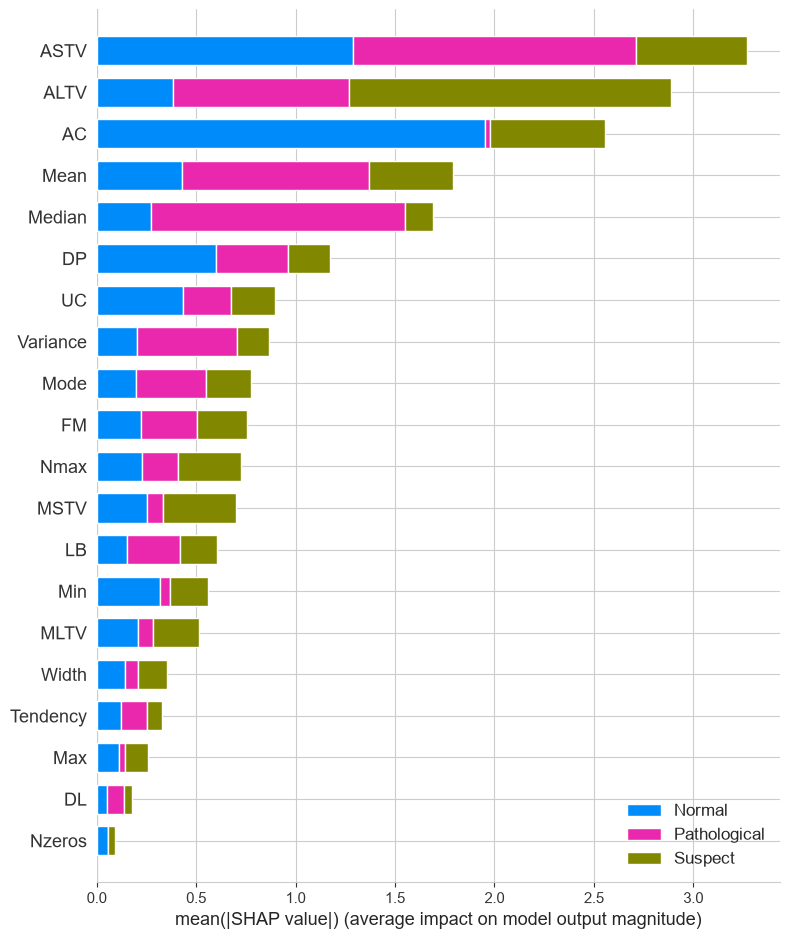

Figure saved: shap_summary.png


In [26]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape if not isinstance(shap_values, list) else f"list of {len(shap_values)} arrays")

# Handle multi-class output: shap_values may be a list of arrays (one per class)
# or a single 3D array depending on the SHAP/XGBoost version
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values
else:
    shap_values_to_plot = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

plt.figure()
shap.summary_plot(
    shap_values_to_plot,
    X_test,
    class_names=["Normal", "Suspect", "Pathological"],
    show=False
)
plt.tight_layout()
plt.savefig("../figures/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: shap_summary.png")

## 7. Modelling Summary

| Model | Accuracy | F1 | ROC-AUC | Pathological Recall |
|-------|----------|-----|---------|---------------------|
| XGBoost (best) | 0.9622 | 0.9610 | 0.9892 | 0.97 |
| LightGBM | 0.9598 | 0.9586 | 0.9893 | 0.94 |
| CatBoost | 0.9574 | 0.9563 | 0.9870 | 0.94 |
| Random Forest | 0.9551 | 0.9539 | 0.9847 | 0.97 |
| Decision Tree | 0.9243 | 0.9243 | 0.8962 | 0.91 |
| SVM | 0.9007 | 0.9069 | 0.9758 | 0.89 |
| Logistic Regression | 0.8818 | 0.8899 | 0.9644 | 0.77 |

**Conclusion:** All four ensemble methods outperformed every baseline model, confirming
the value of the staged methodology proposed in Section 4. XGBoost was selected as the
best-performing model overall, correctly identifying 34/35 Pathological cases with zero
false negatives to the Normal class.

SHAP identified ASTV, ALTV, and AC as the most influential features overall, broadly
consistent with EDA's correlation findings (DP, ASTV, ALTV, AC ranked highest). Minor
differences in ranking (e.g. DP ranking higher in correlation than in SHAP) reflect that
correlation captures simple linear relationships, while SHAP captures the model's actual
learned, non-linear decision patterns.